Jupyter version of the name systems, to find how topology of name systems has changed over time 

In [1]:
# Imports

import gruut
import jellyfish
import numpy as np
from ripser import ripser
from persim import plot_diagrams
import matplotlib.pyplot as plt
import pandas as pd
#import gudhi as gd
import dionysus as d
import itertools as it

#from openpyxl import load_workbook

from phonemizer import phonemize
import panphon
import panphon.distance as pfd
import csv


In [2]:
# Create the distance functions based on espeak package 

def ipa(word, lang="en-gb-x-rp"):
    return phonemize(
        word,
        language=lang,
        backend="espeak",
        strip=True
    )




dst = pfd.Distance()

def feature_distance(w1, w2, lang="en-gb-x-rp"):
    p1 = ipa(w1, lang)
    p2 = ipa(w2, lang)
    return dst.weighted_feature_edit_distance(p1, p2)


# Based on this distance function, as well as using Levenshtein distance between spelling, create a distance matrix for a inputted list of words

def create_dist_mat_2(word_list):
    n = len(word_list)
    #phon_list = []
    #for text in word_list:
    #    for sentence in gruut.sentences(text, lang="en"):
    #        for word in sentence:
    #            phon = "".join(word.phonemes)
    #            phon_list.append(phon)
    #            #print(word.text, word.phonemes)
    ipa_list = [ipa(name) for name in word_list]
    dist_mat = np.zeros([n,n])

    for i in range(n):
        for j in range(i,n):
            names_dist = jellyfish.levenshtein_distance(word_list[i],word_list[j])/max(len(word_list[i]),len(word_list[j]))
            #sound_dist = jellyfish.levenshtein_distance(phon_list[i],phon_list[j])/max(len(phon_list[i]),len(phon_list[j]))
            #dist_mat[i,j] = dist_mat[j,i] = feature_distance(word_list[i], word_list[j])
            d = dst.weighted_feature_edit_distance(
                ipa_list[i],
                ipa_list[j]
            )
            dist_mat[i, j] = dist_mat[j, i] = d + 5 * names_dist
    return dist_mat



## Combining function allowing input to be a dataframe and output to be the matrix needed

def name_mat_weighted_count(df):
    # Get matrix as before
    names = list(df["Name"])
    counts = list(df["Count"])
    n = len(names)
    unweighted_mat = create_dist_mat_2(names)
    '''
    weighted_mat = np.zeros([n,n])
    # Apply weighting function.
    for i in range(n):
        for j in range(n):
            min_count = min(counts[i], counts[j])
            distance = unweighted_mat[i,j]

            scaled = distance + (1-distance) * np.exp(-min_count/20)
            weighted_mat[i,j] = scaled#unweighted_mat[i,j] * scale_factor
    '''
    
    return names, unweighted_mat





# Function to build VR filtration from distance matrix

def build_vr_from_dist_mat(dist, max_dist=np.inf, max_dim=2):
    #dist = unweighted_mat
    n = dist.shape[0]

    filt = d.Filtration()

    #max_dim = 2
    

    for i in range(n):
        filt.append(d.Simplex([i], 0.0))

    

    for i in range(n):
        for j in range(i+1, n):
            if dist[i, j] <= max_dist:
                filt.append(d.Simplex([i, j], dist[i, j]))


    '''
    if max_dim >= 2:
        for i in range(n):
            for j in range(i+1, n):
                for k in range(j+1, n):
                    dmax = max(dist[i,j], dist[i,k], dist[j,k])
                    if dmax <= max_dist:
                        filt.append(d.Simplex([i, j, k], dmax))

    filt.sort()

    return filt
    '''
    # higher dimensional simplices
    for k in range(2, max_dim + 2):   # k = number of vertices
        for simplex in it.combinations(range(n), k):

            # filtration value = largest edge length
            dmax = 0
            for i, j in it.combinations(simplex, 2):
                dmax = max(dmax, dist[i, j])

            if dmax <= max_dist:
                filt.append(d.Simplex(simplex, dmax))

    filt.sort()
    return filt

def build_vr_from_dist_mat(dist, max_dist=np.inf, max_dim=2):
    '''
    n = dist.shape[0]

    distances = []
    for i in range(n):
        for j in range(i+1, n):
            distances.append(dist[i, j])
    '''
    # Build VR filtration
    filt = d.fill_rips(dist, max_dim + 1, max_dist)

    filt.sort()
    return filt

print(feature_distance("ezekielly", "catherine"))
ipa("Michael")

29.75


'maɪkəl'

In [19]:
def distance_between_names(a,b):    
    names_dist = jellyfish.levenshtein_distance(a,b)/max(len(a),len(b))
    #sound_dist = jellyfish.levenshtein_distance(phon_list[i],phon_list[j])/max(len(phon_list[i]),len(phon_list[j]))
    #dist_mat[i,j] = dist_mat[j,i] = feature_distance(word_list[i], word_list[j])
    d = dst.weighted_feature_edit_distance(
        ipa(a),
        ipa(b)
    )
    return d + 5 * names_dist 

def distance_between_names_ir(a,b):  
    names_dist = jellyfish.levenshtein_distance(a,b)/max(len(a),len(b))
    #sound_dist = jellyfish.levenshtein_distance(phon_list[i],phon_list[j])/max(len(phon_list[i]),len(phon_list[j]))
    #dist_mat[i,j] = dist_mat[j,i] = feature_distance(word_list[i], word_list[j])
    d = dst.weighted_feature_edit_distance(
        ipa(a, "ga"),
        ipa(b, "ga"),
    )
    return d + 5 * names_dist 

print(distance_between_names("emma", "eva"))    
print(distance_between_names("evie", "eva")) 
print(distance_between_names("emmie", "evie")) 
print(distance_between_names("emma", "emmie")) 
print(distance_between_names("evie", "emma")) 
print(distance_between_names("emmie", "eva")) 
very_small_names = ["emma", "emma", "eva", "evie", "emmie", "emmie"]
#print(distance_between_names("emmia", "eva")) 
#print(distance_between_names("emmia", "evie")) 
#print(distance_between_names("emmia", "emmie")) 
#print(distance_between_names("emmia", "emma"))

#print(distance_between_names("Rhys", "Reece")) 
#print(distance_between_names("Rhys", "Rays")) 
#print(distance_between_names_ir("Niamh", "Noah")) 
#print(distance_between_names_ir("Niamh", "Nieve")) 
#print(distance_between_names("Sean", "Seen")) 
#print(distance_between_names("Shawn", "Sean")) 

7.5
4.5
5.75
2.75
8.25
9.75


Now apply this to 2024 dataset

In [21]:
### Access the names and the counts into a data frame
df_girls_unprocessed = pd.read_excel("girlsnames2024.xlsx", sheet_name="Table_6")
df_boys_unprocessed = pd.read_excel("boysnames2024.xlsx", sheet_name="Table_6")

# Get rid of empty columns (they just have descriptive text)
df_girls = df_girls_unprocessed.dropna()
df_boys = df_boys_unprocessed.dropna()

# Reformat tables to have the correct headers and only names and counts
df_girls.columns = df_girls.iloc[0]
df_girls = df_girls.iloc[1:]
df_girls = df_girls.drop(df_girls.columns[0], axis=1)
df_boys.columns = df_boys.iloc[0]
df_boys = df_boys.iloc[1:]
df_boys = df_boys.drop(df_boys.columns[0], axis=1)



df_combined = pd.concat([df_girls, df_boys], ignore_index=True)
df_combined = df_combined.sort_values(by="Count", ascending=False)

print(df_combined.head(10))

3         Name Count
7647  Muhammad  5721
7648      Noah  4139
7649    Oliver  3492
7650    Arthur  3368
7651       Leo  3324
7652    George  3257
7653      Luca  2814
0       Olivia  2761
7654  Theodore  2761
7655     Oscar  2747


In [22]:
names, unweighted_mat = name_mat_weighted_count(df_combined.head(n=50))

Diagram with 2 points


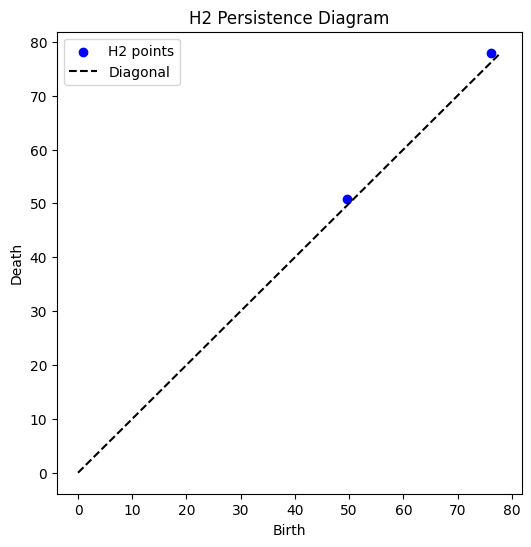

In [23]:
filt = build_vr_from_dist_mat(unweighted_mat, max_dim=3)

homology = d.homology_persistence(filt)
dgms = d.init_diagrams(homology, filt)

h2_points = dgms[2]  # dimension 1

print(h2_points)

births = [pt.birth for pt in h2_points]
deaths = [pt.death for pt in h2_points]

plt.figure(figsize=(6,6))
plt.scatter(births, deaths, color='blue', label='H2 points')
plt.plot([0, max(deaths)], [0, max(deaths)], 'k--', label='Diagonal')  # y=x line
plt.xlabel('Birth')
plt.ylabel('Death')
plt.title('H2 Persistence Diagram')
plt.legend()
plt.show()

In [10]:
# This block allows us to get the actual cycles

H1_cycles = []

for pt in dgms[1]:
    birth = pt.birth
    death = pt.death
    lifespan = death - birth

    # This gives the index of the persistence pair
    pair = homology.pair(pt.data)

    # This is the actual cycle (a Chain)
    chain = homology[pair]

    vertex_indices = set()
    cycle_gen = []

    for entry in chain:             # iterate over ChainEntry objects
        simplex_idx = entry.index   # get the index in filtration
        #coeff = entry.coeff         # get the coefficient
        simplex = filt[simplex_idx] # get the actual simplex
        vertices = list(simplex)    # vertices of the simplex
        for vertex in vertices:
            vert_name = df_combined.iloc[vertex]["Name"]
            if vert_name not in cycle_gen:
                cycle_gen.append(vert_name)
        vertex_indices.update(vertices)
    vertex_indices = sorted(vertex_indices)
    #print("Vertex indices in cycle:", vertex_indices)

    H1_cycles.append({
        "birth": round(birth,3),
        "death": round(death,3),
        "lifespan": round(lifespan,3),
        "chain": cycle_gen
    })


H1_cycles.sort(key=lambda x: x["lifespan"], reverse=True)

In [3]:
def diagram_from_df(df=None, name_list=None, max_dim=2, hom_group=1, max_dist=np.inf, print_pairs=False):
    if name_list is None:
        names, unweighted_mat = name_mat_weighted_count(df)
    else:
        unweighted_mat = create_dist_mat_2(name_list)
    #filt = build_vr_from_dist_mat(unweighted_mat, max_dist=max_dist, max_dim=max_dim)

    #homology = d.homology_persistence(filt)
    #dgms = d.init_diagrams(homology, filt)

    result = ripser(unweighted_mat, distance_matrix=True, maxdim=max_dim)
    dgms = result["dgms"]

    h_points = dgms[hom_group]  # dimension 1
    #deaths = [pt.death if pt.death < np.inf else max_dist for pt in h_points]

    #births = [pt.birth for pt in h_points]
    #deaths = [pt.death for pt in h_points]

    if len(h_points) > 0:
        births = h_points[:,0]
        deaths = h_points[:,1]
    else:
        births = []
        deaths = []
    
    total_len = 0
    
    for i in range(len(births)):
        if print_pairs:
            print("cycle born:", births[i], "cycle dead", deaths[i])
        total_len += float(deaths[i] - births[i])

    av_len = total_len/len(births)
    finite_deaths = [d for d in deaths if np.isfinite(d)]
    max_finite = max(finite_deaths) if finite_deaths else 0

    # replace infinity
    deaths = [d if np.isfinite(d) else max_finite + 1 for d in deaths]

    '''
    plt.figure(figsize=(6,6))
    plt.scatter(births, deaths, color='blue', label=f"H{hom_group} points")
    plt.plot([0, max(deaths)], [0, max(deaths)], 'k--', label='Diagonal')  # y=x line
    plt.xlabel('Birth')
    plt.ylabel('Death')
    plt.title(f"H{hom_group} Persistence Diagram")
    plt.legend()
    plt.show()
    '''

    fig, ax = plt.subplots(figsize=(6,6))

    ax.scatter(births, deaths, color='blue', label=f"H{hom_group} points")

    if deaths:  # avoid crash if empty
        m = max(deaths)
        ax.plot([0, m], [0, m], 'k--', label='Diagonal')

    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(f"H{hom_group} Persistence Diagram")
    ax.legend()

    #plt.show()

    return fig, ax, av_len

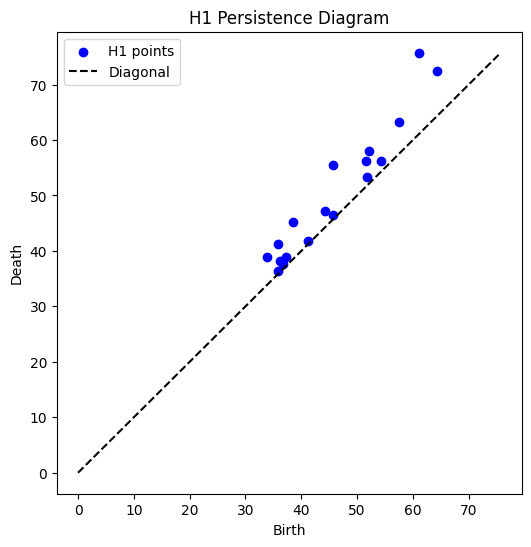

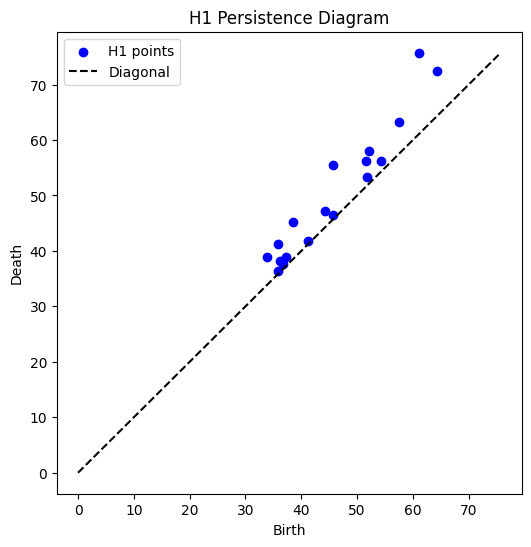

In [ ]:
# Now we will check that the function above works as planned

fig, ax, _ = diagram_from_df(df_combined.head(n=50), max_dim=2, hom_group=1)
fig

In [4]:
# Henry the VIIIth pre and post data
with open('before_VIII.csv', newline='') as csvfile:
    for row in csvfile:
        pre_VIII = row.split(", ")

pre_VIII = pre_VIII[1:]

with open('after_VIII.csv', newline='') as csvfile:
    for row in csvfile:
        post_VIII = row.split(", ")

post_VIII = post_VIII[1:]

with open('after_VIII_2.csv', newline='') as csvfile:
    for row in csvfile:
        post_VIII_2 = row.split(", ")

post_VIII_2 = post_VIII_2[1:]

print(pre_VIII)

['John', 'Thomas', 'William', 'Robert', 'Richard', 'Henry', 'Nicholas', 'James', 'Edmund', 'George', 'Edward', 'Peter', 'Walter', 'Roger', 'Alexander', 'Andrew', 'Christopher', 'Ralph', 'David', 'Adam', 'Matthew', 'Simon', 'Akeman', 'Anthony', 'Miles', 'Gawaine', 'Hugh', 'Ambrose', 'Augustin', 'Gregory', 'Humphrey', 'Laurence', 'Martin', 'Michael', 'Silvester', 'Stephen', 'Attwell', 'Benedict', 'Cornelius', 'Elyas', 'Francis', 'Fulk', 'Gabriel', 'Giles', 'Godfrey', 'Griffin', 'Hamo', 'Jasper', 'Lancelot', 'Leonard', 'Luke', 'Mark', 'Marmaduke', 'Maximillian', 'Norman', 'Odbert', 'Oliver', 'Philip', 'Randall', 'Reynold', 'Reginald', 'Vivian']


1.7698012457953558

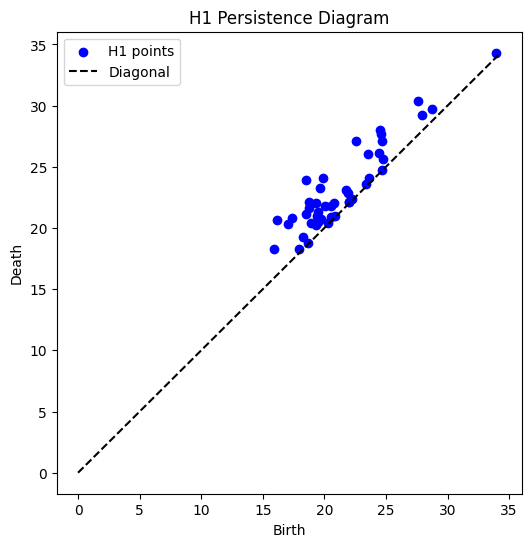

In [5]:
fig, ax, total_pre_VIII = diagram_from_df(name_list=pre_VIII)

total_pre_VIII

1.9728714869572566

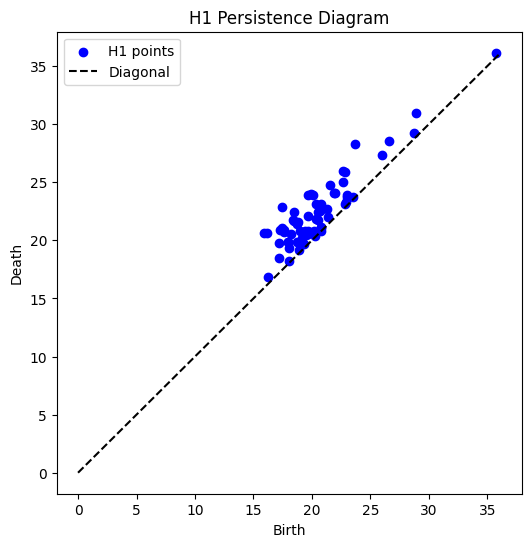

In [6]:
fig, ax, total_post_VIII = diagram_from_df(name_list=post_VIII)

total_post_VIII

1.9780701838041608

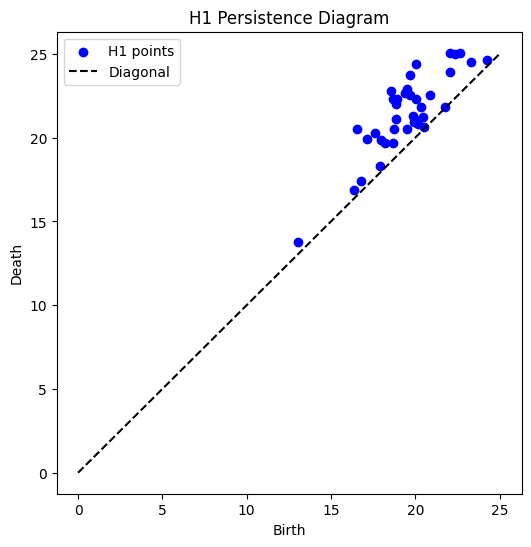

In [7]:
fig, ax, total_post_VIII_2 = diagram_from_df(name_list=post_VIII_2)

total_post_VIII_2

In [21]:
# Now, look at pre and post conquest
with open('pre_conquest.csv', newline='') as csvfile:
    for row in csvfile:
        pre_conquest = row.split(", ")

pre_conquest = pre_conquest[1:]

with open('post_conquest.csv', newline='') as csvfile:
    for row in csvfile:
        post_conquest = row.split(", ")

post_conquest= post_conquest[1:]

with open('names_1200_99.csv', newline='') as csvfile:
    for row in csvfile:
        
        names_1200_99 = row.split(", ")

names_1200_99= names_1200_99[1:]

with open('names_1300_99.csv', newline='') as csvfile:
    for row in csvfile:
        names_1300_99 = row.split(", ")

names_1300_99= names_1300_99[1:]

with open('names_1400_99.csv', newline='') as csvfile:
    for row in csvfile:
        names_1400_99 = row.split(", ")

names_1400_99= names_1400_99[1:]

2.6961154184843363

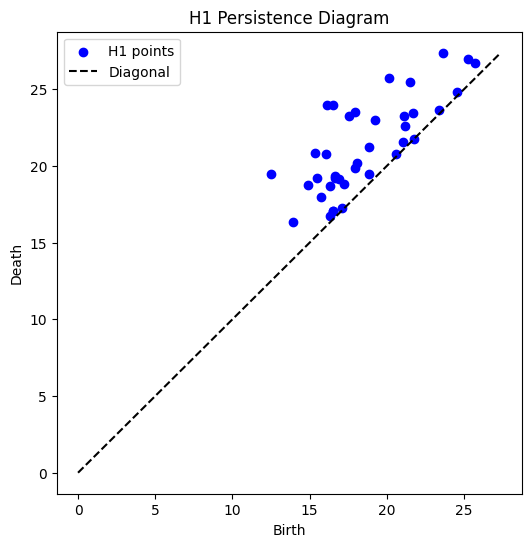

In [9]:
fig, ax, av_len_pre_conquest = diagram_from_df(name_list=pre_conquest)

av_len_pre_conquest

1.7485449896918404

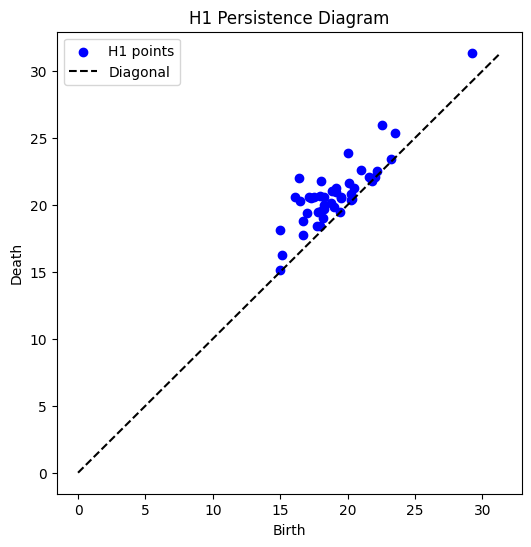

In [10]:
fig, ax, av_len_post_conquest = diagram_from_df(name_list=post_conquest)

av_len_post_conquest

1.5715811069195087

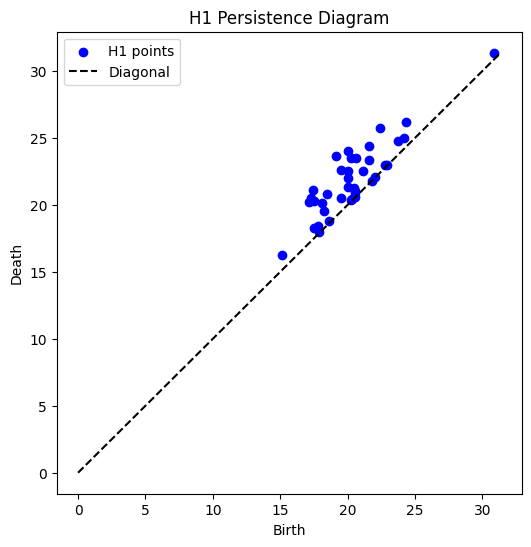

In [22]:
fig, ax, av_len_1200_99 = diagram_from_df(name_list=names_1200_99)

av_len_1200_99

1.425958028653773

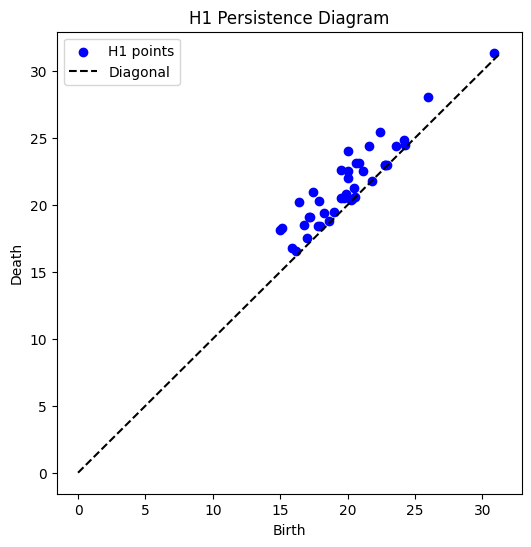

In [23]:
fig, ax, av_len_1300_99 = diagram_from_df(name_list=names_1300_99)

av_len_1300_99

2.0451787125830556

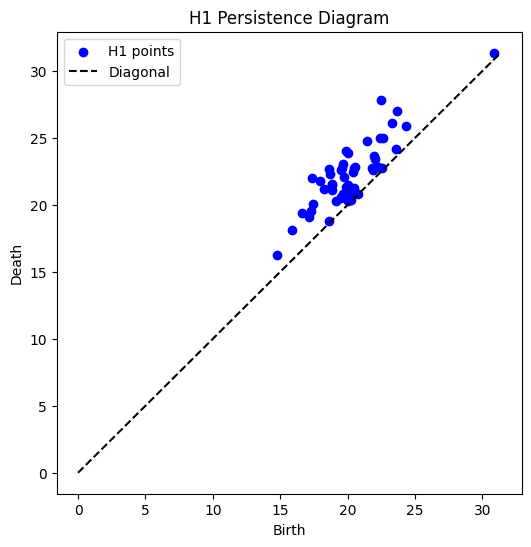

In [24]:
fig, ax, av_len_1400_99 = diagram_from_df(name_list=names_1400_99)

av_len_1400_99

1.7698012457953558

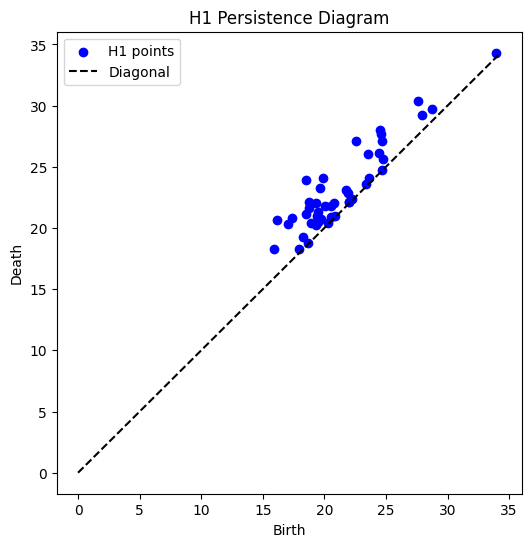

In [25]:
fig, ax, av_pre_VIII = diagram_from_df(name_list=pre_VIII)

av_pre_VIII

1.9780701838041608

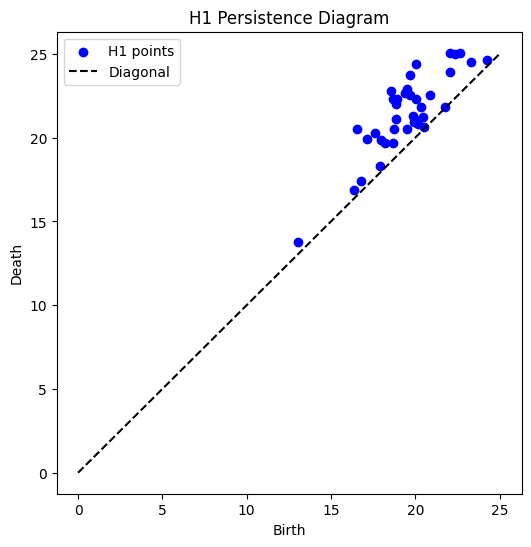

In [5]:
fig, ax, av_post_VIII_2 = diagram_from_df(name_list=post_VIII_2)

av_post_VIII_2

In [6]:
print(av_len_pre_conquest, av_len_post_conquest, av_len_1200_99, av_len_1300_99, av_len_1400_99, av_pre_VIII, av_post_VIII_2)

NameError: name 'av_len_pre_conquest' is not defined

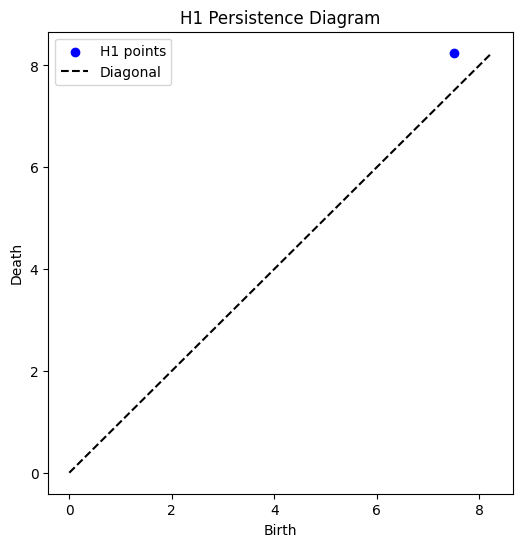

In [29]:
fig, ax = diagram_from_df(name_list=very_small_names, hom_group=1)

In [12]:
# New data list to look at "filling in" or creating holes

names_hole = ["Alfie", "Aelfwyn", "Arwyn", "Marwyn", "Marvin", "Martin", "Martina", "Marina", "Maria", "Marie", "Maline", "Aline", "Allie"]
names_filled = ["Marwyn","Alfina","Alfie", "Aelfwyn", "Arwyn", "Marwyn", "Marvin", "Martin", "Martina", "Marina", "Maria", "Marie", "Maline", "Aline", "Allie"]
names_broken = ["Alfie", "Arwyn", "Marwyn", "Marvin", "Martin", "Martina", "Marina", "Maria", "Marie", "Maline", "Aline", "Allie"]
smaller_unfilled_hally = ["Molly", "Polly", "Hallie", "Holly", "Pallie", "Hally"]
smaller_unfilled_no_hally = ["Molly", "Polly", "Hallie", "Holly", "Pallie"]


Next one
1.75 2.25


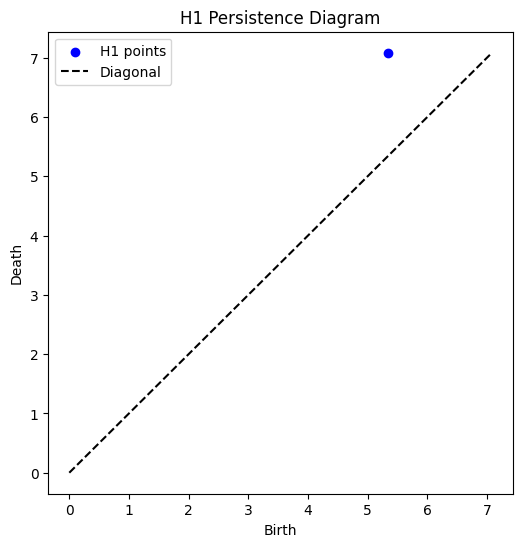

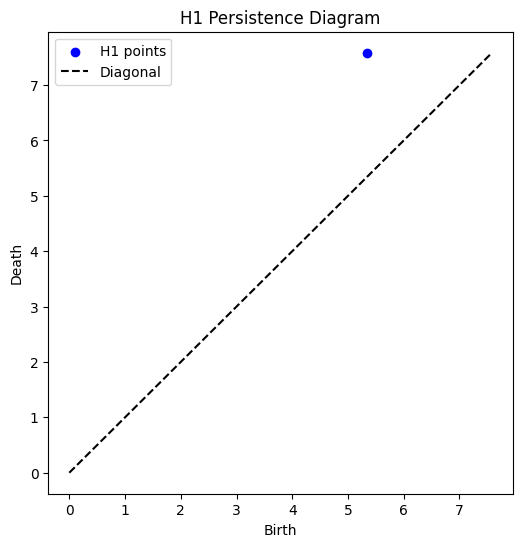

In [13]:
fig, ax, hally_av_len = diagram_from_df(name_list=smaller_unfilled_hally, hom_group=1)
print("Next one")
fig, ax, no_hally_av_len = diagram_from_df(name_list=smaller_unfilled_no_hally, hom_group=1)

print(hally_av_len, no_hally_av_len)

In [10]:
# We now want to look at applying this to the set of top names accross time
# this is stored in the historical names data excel sheet


### Access the names and the counts into a data frame
df_girls_unprocessed = pd.read_excel("historicalnames2024.xlsx", sheet_name="Table_1")
df_boys_unprocessed = pd.read_excel("historicalnames2024.xlsx", sheet_name="Table_2")

# Get rid of empty columns (they just have descriptive text)
df_girls = df_girls_unprocessed.dropna()
df_boys = df_boys_unprocessed.dropna()

df_girls.columns = df_girls.iloc[0]
df_girls = df_girls.iloc[1:]
df_girls = df_girls.drop(df_girls.columns[0], axis=1)

# Same to the boys now
df_boys.columns = df_boys.iloc[0]
df_boys = df_boys.iloc[1:]
df_boys = df_boys.drop(df_boys.columns[0], axis=1)

year_name_lists_girls = {}
for i in range(13):
    year = 1904 + i*10
    name_list = df_girls[year].to_list()

    year_name_lists_girls[year] = name_list

'''
# Reformat tables to have the correct headers and only names and counts
df_girls.columns = df_girls.iloc[0]
df_girls = df_girls.iloc[1:]
df_girls = df_girls.drop(df_girls.columns[0], axis=1)
df_boys.columns = df_boys.iloc[0]
df_boys = df_boys.iloc[1:]
df_boys = df_boys.drop(df_boys.columns[0], axis=1)



df_combined = pd.concat([df_girls, df_boys], ignore_index=True)
df_combined = df_combined.sort_values(by="Count", ascending=False)

print(df_combined.head(10))
'''

'\n# Reformat tables to have the correct headers and only names and counts\ndf_girls.columns = df_girls.iloc[0]\ndf_girls = df_girls.iloc[1:]\ndf_girls = df_girls.drop(df_girls.columns[0], axis=1)\ndf_boys.columns = df_boys.iloc[0]\ndf_boys = df_boys.iloc[1:]\ndf_boys = df_boys.drop(df_boys.columns[0], axis=1)\n\n\n\ndf_combined = pd.concat([df_girls, df_boys], ignore_index=True)\ndf_combined = df_combined.sort_values(by="Count", ascending=False)\n\nprint(df_combined.head(10))\n'

In [ ]:
# Now we apply the function to each year and see what we get
fig_1904, ax_1904 = diagram_from_df(name_list=year_name_lists_girls[1904])

In [ ]:
fig, ax = fig_1904, ax_1904

plt.show()